# Develop an LSTM-based model for time-series forecasting using stock price, weather, or sales datasets. 

#### Import the libraries

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

#### Load sales.csv

In [33]:
df = pd.read_csv("Dataset/sales.csv")

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
   Unnamed: 0        date       item_id  quantity  price_base  sum_total  \
0           0  2023-08-04  293375605257     1.000       47.86      47.86   
1           1  2023-08-04  a66fdf2c0ae7     3.000       49.60     148.80   
2           2  2023-08-04  daa46ef49b7a     0.822      379.00     311.54   
3           3  2023-08-04  a3b49c1bf758     1.000      129.00     129.00   
4           4  2023-08-04  ab611c5cef62     7.000       79.90     559.30   

   store_id  
0         1  
1         1  
2         1  
3         1  
4         1  


#### Check the dataset

In [34]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (7432685, 7)

Column Names:
['Unnamed: 0', 'date', 'item_id', 'quantity', 'price_base', 'sum_total', 'store_id']

Data Types:
Unnamed: 0      int64
date           object
item_id        object
quantity      float64
price_base    float64
sum_total     float64
store_id        int64
dtype: object

Missing Values:
Unnamed: 0    0
date          0
item_id       0
quantity      0
price_base    0
sum_total     0
store_id      0
dtype: int64


#### Prepare the time-series data

##### Remove the unnecessary index column

In [35]:
df = df.drop(columns=["Unnamed: 0"])

print(df.columns)

Index(['date', 'item_id', 'quantity', 'price_base', 'sum_total', 'store_id'], dtype='object')


##### Convert date to datetime

In [36]:
df["date"] = pd.to_datetime(df["date"])

print(df["date"].dtype)

datetime64[ns]


##### Check the date range

In [37]:
print("Starting date:", df["date"].min())
print("Ending date:", df["date"].max())

print("Number of unique dates:", df["date"].nunique())

Starting date: 2022-08-28 00:00:00
Ending date: 2024-09-26 00:00:00
Number of unique dates: 761


##### Aggregate sales by date

In [38]:
daily_sales = (
    df.groupby("date")["sum_total"]
      .sum()
      .reset_index()
)

daily_sales = daily_sales.sort_values("date")

print(daily_sales.head())
print("\nShape:", daily_sales.shape)

        date   sum_total
0 2022-08-28  3900982.29
1 2022-08-29  4563923.94
2 2022-08-30  4532956.77
3 2022-08-31  5149001.14
4 2022-09-01  6696774.65

Shape: (761, 2)


##### Check for missing values

In [39]:
print("Missing dates:", daily_sales["date"].isnull().sum())
print("Missing sales:", daily_sales["sum_total"].isnull().sum())

Missing dates: 0
Missing sales: 0


#### Visualize and analyze the time series

##### Plot the complete daily sales

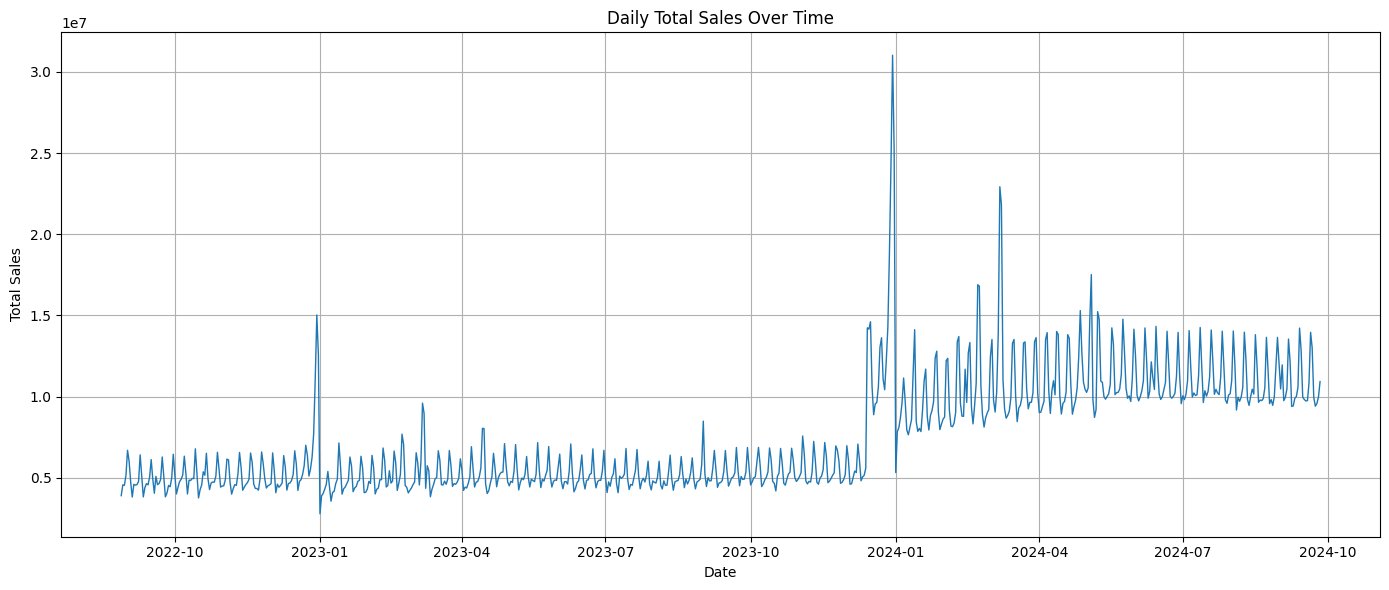

In [40]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_sales["date"],
    daily_sales["sum_total"],
    linewidth=1
)

plt.title("Daily Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.grid(True)
plt.tight_layout()
plt.show()

##### Calculate basic statistics

In [41]:
print("Mean sales:", daily_sales["sum_total"].mean())
print("Minimum sales:", daily_sales["sum_total"].min())
print("Maximum sales:", daily_sales["sum_total"].max())
print("Standard deviation:", daily_sales["sum_total"].std())

Mean sales: 7435416.13759527
Minimum sales: 2784856.37
Maximum sales: 31018818.5
Standard deviation: 3424895.5854940233


##### Check whether any dates are missing

In [42]:
date_range = pd.date_range(
    start=daily_sales["date"].min(),
    end=daily_sales["date"].max(),
    freq="D"
)

missing_dates = date_range.difference(daily_sales["date"])

print("Expected number of dates:", len(date_range))
print("Actual number of dates:", len(daily_sales))
print("Missing dates:", len(missing_dates))

if len(missing_dates) > 0:
    print("\nMissing dates:")
    print(missing_dates)

Expected number of dates: 761
Actual number of dates: 761
Missing dates: 0


##### Check the last few records

In [43]:
daily_sales.tail(10)

,date,sum_total
751,2024-09-17,9732224.06
752,2024-09-18,9752550.94
753,2024-09-19,10848699.09
754,2024-09-20,13960987.75
755,2024-09-21,13001838.34
756,2024-09-22,9972718.14
757,2024-09-23,9410004.72
758,2024-09-24,9575443.52
759,2024-09-25,9980670.27
760,2024-09-26,10924785.57


#### Train/Test Split

##### Create the training and testing data

In [44]:
# Number of observations
n = len(daily_sales)

# 80% for training
train_size = int(n * 0.80)

# Split chronologically
train_data = daily_sales.iloc[:train_size].copy()
test_data = daily_sales.iloc[train_size:].copy()

print("Total observations:", n)
print("Training observations:", len(train_data))
print("Testing observations:", len(test_data))

print("\nTraining period:")
print(train_data["date"].min(), "to", train_data["date"].max())

print("\nTesting period:")
print(test_data["date"].min(), "to", test_data["date"].max())

Total observations: 761
Training observations: 608
Testing observations: 153

Training period:
2022-08-28 00:00:00 to 2024-04-26 00:00:00

Testing period:
2024-04-27 00:00:00 to 2024-09-26 00:00:00


#### Normalize the sales values

##### Create the scaler

In [45]:
scaler = MinMaxScaler(feature_range=(0, 1))

##### Fit only on training data

In [46]:
train_scaled = scaler.fit_transform(
    train_data[["sum_total"]]
)

test_scaled = scaler.transform(
    test_data[["sum_total"]]
)

print("Training scaled shape:", train_scaled.shape)
print("Testing scaled shape:", test_scaled.shape)

Training scaled shape: (608, 1)
Testing scaled shape: (153, 1)


#### Create LSTM sequences

##### Create the sequence function

In [47]:
def create_sequences(data, time_steps):
    X = []
    y = []

    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i, 0])
        y.append(data[i, 0])

    return np.array(X), np.array(y)

##### Create training sequences

In [48]:
TIME_STEPS = 30

X_train, y_train = create_sequences(
    train_scaled,
    TIME_STEPS
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (578, 30)
y_train shape: (578,)


#### Prepare the test sequences

In [49]:
test_input = np.concatenate(
    (train_scaled[-TIME_STEPS:], test_scaled),
    axis=0
)

X_test, y_test = create_sequences(
    test_input,
    TIME_STEPS
)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (153, 30)
y_test shape: (153,)


#### Reshape the data for LSTM

In [50]:
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print("Final X_train shape:", X_train.shape)
print("Final X_test shape:", X_test.shape)

Final X_train shape: (578, 30, 1)
Final X_test shape: (153, 30, 1)


#### Build the LSTM model

##### Create the model

In [51]:
model = Sequential()

model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

model.add(Dropout(0.2))

model.add(
    LSTM(32)
)

model.add(Dropout(0.2))

model.add(Dense(1))

d:\Third Year\DL\Assignments\Exp_4\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


##### Compile the model

In [52]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

##### Display the architecture

In [53]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

#### Train the LSTM

In [54]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss: 0.0087 - val_loss: 0.0224
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0061 - val_loss: 0.0108
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0059 - val_loss: 0.0125
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0060 - val_loss: 0.0122
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0056 - val_loss: 0.0111
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0054 - val_loss: 0.0115
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0056 - val_loss: 0.0110
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0053 - val_loss: 0.0120
Epoch 9/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0053 - val_loss: 0.0119
Epoch 10/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0056 - val_loss: 0.0111
Epoch 11/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0056 - val_loss: 0.0115
Epoch 12/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0

#### Plot training and validation loss

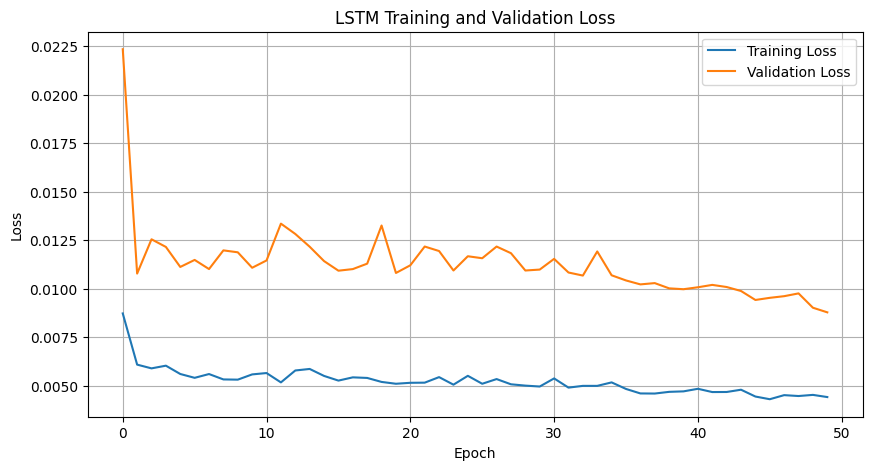

In [55]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)
plt.show()

#### Generate predictions

In [56]:
predictions_scaled = model.predict(X_test)

print("Prediction shape:", predictions_scaled.shape)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 183ms/step
Prediction shape: (153, 1)


#### Convert predictions back to actual sales values

In [57]:
predictions = scaler.inverse_transform(predictions_scaled)

actual = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

print("First 5 actual values:")
print(actual[:5])

print("\nFirst 5 predicted values:")
print(predictions[:5])

First 5 actual values:
[[15297579.53]
 [12709267.38]
 [10896781.26]
 [10457702.69]
 [10260502.62]]

First 5 predicted values:
[[11021716.]
 [12065575.]
 [11774883.]
 [11137473.]
 [10770238.]]


#### Calculate RMSE and MAE

In [58]:
rmse = np.sqrt(
    mean_squared_error(actual, predictions)
)

mae = mean_absolute_error(
    actual, predictions
)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 1710432.2197137075
MAE: 1247802.8124183004


#### Calculate Mean Absolute Percentage Error

In [59]:
mape = np.mean(
    np.abs((actual - predictions) / actual)
) * 100

print("MAPE:", mape, "%")

MAPE: 10.557399184673203 %


#### Create the Actual vs Predicted graph

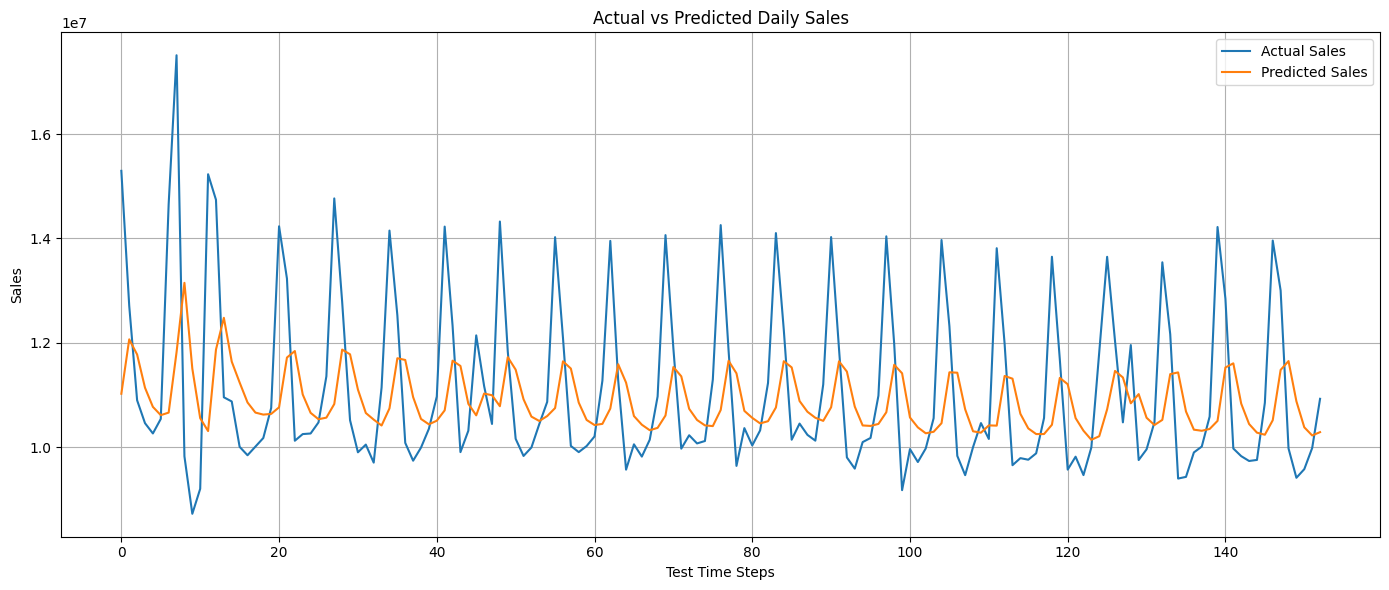

In [60]:
plt.figure(figsize=(14, 6))

plt.plot(
    actual,
    label="Actual Sales"
)

plt.plot(
    predictions,
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Daily Sales")
plt.xlabel("Test Time Steps")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

#### Create a results table

In [61]:
results = pd.DataFrame({
    "Actual Sales": actual.flatten(),
    "Predicted Sales": predictions.flatten()
})

results["Absolute Error"] = abs(
    results["Actual Sales"] -
    results["Predicted Sales"]
)

results.head(10)

,Actual Sales,Predicted Sales,Absolute Error
0,15297579.53,11021716.0,4275863.53
1,12709267.38,12065575.0,643692.38
2,10896781.26,11774883.0,878101.74
3,10457702.69,11137473.0,679770.31
4,10260502.62,10770238.0,509735.38
5,10538979.80,10611224.0,72244.20
6,14658020.37,10660173.0,3997847.37
7,17514795.75,11817063.0,5697732.75
8,9822027.02,13149432.0,3327404.98
9,8719174.18,11504638.0,2785463.82


In [62]:
rmse = np.sqrt(mean_squared_error(actual, predictions))
mae = mean_absolute_error(actual, predictions)

mape = np.mean(
    np.abs((actual - predictions) / actual)
) * 100

print("Model Evaluation")
print("-----------------")
print(f"RMSE : {rmse:,.2f}")
print(f"MAE  : {mae:,.2f}")
print(f"MAPE : {mape:.2f}%")

Model Evaluation
-----------------
RMSE : 1,710,432.22
MAE  : 1,247,802.81
MAPE : 10.56%
